# RQ5 — Housing Inequity Sensitivity across Population Groups
## Do different population groups experience housing inequity differently under the same objective housing conditions?

**Research Hypotheses (α = 0.05)**
- **H1 (Objective stress)**: Within the same HEI quintile, LSOAs with higher shares of low-income, low NS-SEC, multi-child, or elderly populations show significantly greater objective housing deprivation stress
- **H2 (Perceived sensitivity)**: Different population groups show differentiated sensitivity to specific housing deficits (youth → transport; elderly → healthcare; families with children → overcrowding; low-income → house prices)
- **H3 (Spatial pattern)**: "Poor housing + vulnerable populations" form contiguous double-deprivation clusters; "good housing + advantaged populations" form contiguous double-advantage zones

**Analytical framework**: Population clustering → ANOVA (objective stress) → Spearman sensitivity analysis → Spatial double-deprivation → Demographic-adjusted HEI

## Section 1 — Data Loading & Feature Engineering

In [25]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import seaborn as sns
from scipy import stats
from scipy.stats import f_oneway, kruskal, chi2_contingency, spearmanr
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import geopandas as gpd
import glob

warnings.filterwarnings('ignore')

BASE     = os.path.dirname(os.path.abspath('__file__'))
DATA_DIR = os.path.join(BASE, 'data')
FIG_DIR  = os.path.join(BASE, 'figures')
os.makedirs(FIG_DIR, exist_ok=True)

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})
print('✓ Imports OK')

✓ Imports OK


In [26]:
# --- 1.1  Load HEI master (deduplicated on lsoa21cd) -------------------------
hei_raw = pd.read_csv(os.path.join(DATA_DIR, 'master_southwark_hei.csv'))
print(f'Raw HEI rows: {len(hei_raw)} | lsoa21cd unique: {hei_raw["lsoa21cd"].nunique()}')

# Deduplicate: keep first occurrence per lsoa21cd
hei = hei_raw.drop_duplicates(subset=['lsoa21cd'], keep='first').copy()
hei = hei.reset_index(drop=True)
print(f'After dedup: {len(hei)} rows | HEI_bayes NaN: {hei["HEI_bayes"].isnull().sum()}')

HEI_COMPONENTS = ['overcrowding_proxy', 'transport_ptai', 'hospital',
                   'median_house_price', 'avg_epc_rating_num']

# Quick sanity
print(f'\nHEI_quintile distribution:')
print(hei['HEI_quintile'].value_counts().sort_index())

Raw HEI rows: 3216 | lsoa21cd unique: 173
After dedup: 173 rows | HEI_bayes NaN: 0

HEI_quintile distribution:
HEI_quintile
Q1 (best)     32
Q2            34
Q3            42
Q4            31
Q5 (worst)    34
Name: count, dtype: int64


In [27]:
# --- 1.2  Load Census 2021 demographic files (Southwark LSOAs) ---------------
SOUTHWARK = 'Southwark'

def load_census(fn, sheet='2021'):
    df = pd.read_excel(os.path.join(DATA_DIR, fn), sheet_name=sheet)
    la_col = [c for c in df.columns if 'local authority name' in c.lower()][0]
    return df[df[la_col].str.contains(SOUTHWARK, na=False)].copy()

health  = load_census('census2021_general_health_southwark_lsoa.xlsx')
nssec   = load_census('census2021_nssec_southwark_lsoa.xlsx')
hhcomp  = load_census('census2021_household_composition_southwark_lsoa.xlsx')
commute = load_census('census2021_commute_distance_southwark_lsoa.xlsx')
depriv  = load_census('census2021_household_deprivation_southwark_lsoa.xlsx')
hhsize  = load_census('census2021_household_size_southwark_lsoa.xlsx')

for name, df in [('health',health),('nssec',nssec),('hhcomp',hhcomp),
                 ('commute',commute),('depriv',depriv),('hhsize',hhsize)]:
    print(f'{name}: {len(df)} rows')

health: 173 rows
nssec: 173 rows
hhcomp: 173 rows
commute: 173 rows
depriv: 173 rows
hhsize: 173 rows


In [28]:
# --- 1.3  Feature engineering: compute proportion-based demographic indicators --

# Health: proportion with poor/fair health
h = health.copy()
h['pct_poor_health']  = (h['Bad health'] + h['Very bad health']) / h['All Usual residents ']
h['pct_fair_health']  = h['Fair health'] / h['All Usual residents ']
h['pct_good_health']  = (h['Very good health'] + h['Good health']) / h['All Usual residents ']
health_feat = h[['LSOA code', 'pct_poor_health', 'pct_fair_health', 'pct_good_health']]

# NS-SEC: % high managerial vs. % routine/manual/unemployed
n = nssec.copy()
total = n['All usual residents aged 16+']
n['pct_high_nssec']  = (n['Higher managerial admin and professional '] +
                         n['Lower managerial admin and professional ']) / total
n['pct_low_nssec']   = (n['Semi routine'] + n['Routine '] +
                         n['Never worked and long term unemployed']) / total
n['pct_intermediate'] = n['Intermediate '] / total
nssec_feat = n[['LSOA code', 'pct_high_nssec', 'pct_low_nssec', 'pct_intermediate']]

# Household composition
hc = hhcomp.copy()
tot_hh = hc['All households']
hc['pct_elderly_alone']   = hc['One person Aged 66+'] / tot_hh
hc['pct_single']          = (hc['One person Aged 66+'] + hc['One person Aged up to 65']) / tot_hh
hc['pct_dep_children']    = (hc['Married or civil partnership couple: Dependent children'] +
                              hc['Cohabiting couple: Dependent children'] +
                              hc['Lone parent: dependent children'] +
                              hc['Other with dependent children']) / tot_hh
hc['pct_lone_parent']     = hc['Lone parent: dependent children'] / tot_hh
hhcomp_feat = hc[['LSOA code', 'pct_elderly_alone', 'pct_single',
                   'pct_dep_children', 'pct_lone_parent']]

# Commute distance: % long commute (≥20km, proxy for transport burden)
cm = commute.copy()
tot_emp = cm['All usual residents aged 16+ in employment']
cm['pct_long_commute']  = (cm['20km to less than 30km'] + cm['30km to less than 40km'] +
                            cm['40km to less than 60km'] + cm['60km and over']) / tot_emp
cm['pct_home_work']     = cm['Works mainly from home'] / tot_emp
cm['pct_short_commute'] = (cm['Less than 2km'] + cm['2km to less than 5km']) / tot_emp
commute_feat = cm[['LSOA code', 'pct_long_commute', 'pct_home_work', 'pct_short_commute']]

# Household deprivation dimensions
dv = depriv.copy()
tot_d = dv['All Households']
dv['pct_deprived_any']   = (tot_d - dv['deprived in: no dimensions']) / tot_d
dv['pct_deprived_2plus'] = (dv['2 dimensions'] + dv['3 dimensions'] + dv['4 dimensions']) / tot_d
depriv_feat = dv[['LSOA code', 'pct_deprived_any', 'pct_deprived_2plus']]

# Household size: % large household (5+ people, proxy for overcrowding risk)
hs = hhsize.copy()
tot_s = hs['All Households']
hs['pct_large_hh']  = (hs['5 people in household'] + hs['6 people in household'] +
                        hs['7 people in household'] + hs['8 or more people in household']) / tot_s
hs['pct_small_hh']  = (hs['1 person in household'] + hs['2 people in household']) / tot_s
hhsize_feat = hs[['LSOA code', 'pct_large_hh', 'pct_small_hh']]

print('✓ Demographic features computed')
for name, df in [('health_feat', health_feat), ('nssec_feat', nssec_feat),
                 ('hhcomp_feat', hhcomp_feat), ('commute_feat', commute_feat),
                 ('depriv_feat', depriv_feat), ('hhsize_feat', hhsize_feat)]:
    print(f'  {name}: {df.shape}  NaN={df.isnull().sum().sum()}')

✓ Demographic features computed
  health_feat: (173, 4)  NaN=0
  nssec_feat: (173, 4)  NaN=0
  hhcomp_feat: (173, 5)  NaN=0
  commute_feat: (173, 4)  NaN=0
  depriv_feat: (173, 3)  NaN=0
  hhsize_feat: (173, 3)  NaN=0


In [29]:
# --- 1.4  Merge all features into analysis master ------------------------------
demo_dfs = [health_feat, nssec_feat, hhcomp_feat, commute_feat, depriv_feat, hhsize_feat]
demo = demo_dfs[0].copy()
for d in demo_dfs[1:]:
    demo = demo.merge(d, on='LSOA code', how='outer')

# Join HEI onto demographic data via lsoa21cd
master = hei.merge(demo, left_on='lsoa21cd', right_on='LSOA code', how='left')
print(f'Master: {master.shape}  |  NaN in HEI_bayes: {master["HEI_bayes"].isnull().sum()}')

# Fill any NaN in demographic proportions with median
DEMO_COLS = [c for c in master.columns if c.startswith('pct_')]
for col in DEMO_COLS:
    n = master[col].isnull().sum()
    if n:
        master[col] = master[col].fillna(master[col].median())
        print(f'  {col}: {n} NaN filled')

print(f'\nDemographic columns ({len(DEMO_COLS)}): {DEMO_COLS}')
master[DEMO_COLS + ['HEI_bayes', 'HEI_quintile']].describe().T.round(3)

Master: (173, 53)  |  NaN in HEI_bayes: 0

Demographic columns (18): ['pct_epc_ABC', 'pct_poor_health', 'pct_fair_health', 'pct_good_health', 'pct_high_nssec', 'pct_low_nssec', 'pct_intermediate', 'pct_elderly_alone', 'pct_single', 'pct_dep_children', 'pct_lone_parent', 'pct_long_commute', 'pct_home_work', 'pct_short_commute', 'pct_deprived_any', 'pct_deprived_2plus', 'pct_large_hh', 'pct_small_hh']


,count,mean,std,min,25%,50%,75%,max
pct_epc_ABC,173.0,45.910,14.612,0.605,36.571,46.624,57.015,75.962
pct_poor_health,173.0,0.041,0.015,0.007,0.031,0.041,0.049,0.104
pct_fair_health,173.0,0.097,0.022,0.043,0.084,0.098,0.110,0.156
pct_good_health,173.0,0.862,0.036,0.741,0.842,0.861,0.882,0.949
pct_high_nssec,173.0,0.427,0.137,0.162,0.311,0.410,0.537,0.787
pct_low_nssec,173.0,0.263,0.105,0.042,0.173,0.275,0.357,0.448
pct_intermediate,173.0,0.080,0.015,0.030,0.069,0.081,0.091,0.115
pct_elderly_alone,173.0,0.074,0.030,0.002,0.055,0.070,0.089,0.179
pct_single,173.0,0.329,0.061,0.159,0.291,0.328,0.366,0.507
pct_dep_children,173.0,0.255,0.081,0.053,0.201,0.257,0.305,0.465


In [30]:
# --- 1.5  Load Southwark shapefile -------------------------------------------
SHP_DIR = os.path.join(BASE, 'LSOA_Shapfile')
shp_files = glob.glob(os.path.join(SHP_DIR, '*.shp'))
lsoa_gdf  = gpd.read_file(shp_files[0]).to_crs(epsg=27700)
geo_col   = [c for c in lsoa_gdf.columns if 'cd' in c.lower() or 'code' in c.lower()][0]

southwark_codes = set(master['lsoa21cd'].dropna()) | set(master['lsoa11cd'].dropna())
geo_swk = lsoa_gdf[lsoa_gdf[geo_col].isin(southwark_codes)].copy()

join_key = 'lsoa21cd' if geo_swk[geo_col].isin(master['lsoa21cd']).mean() > 0.5 else 'lsoa11cd'
geo_master = geo_swk.merge(master.drop_duplicates(subset=[join_key]),
                            left_on=geo_col, right_on=join_key, how='left')
print(f'Shapefile: {len(geo_swk)} polygons  |  after merge: {len(geo_master)}')
print(f'NaN in HEI_bayes after geo-merge: {geo_master["HEI_bayes"].isnull().sum()}')

Shapefile: 173 polygons  |  after merge: 173
NaN in HEI_bayes after geo-merge: 0


## Section 2 — Population-type Cluster Analysis

K-means clustering on 173 Southwark LSOAs using Census 2021 demographic proportion variables, identifying four population-type zones for H1/H2 analysis.

**Clustering variables**: general health, NS-SEC occupational class, household composition, commute distance, household deprivation dimensions, household size.

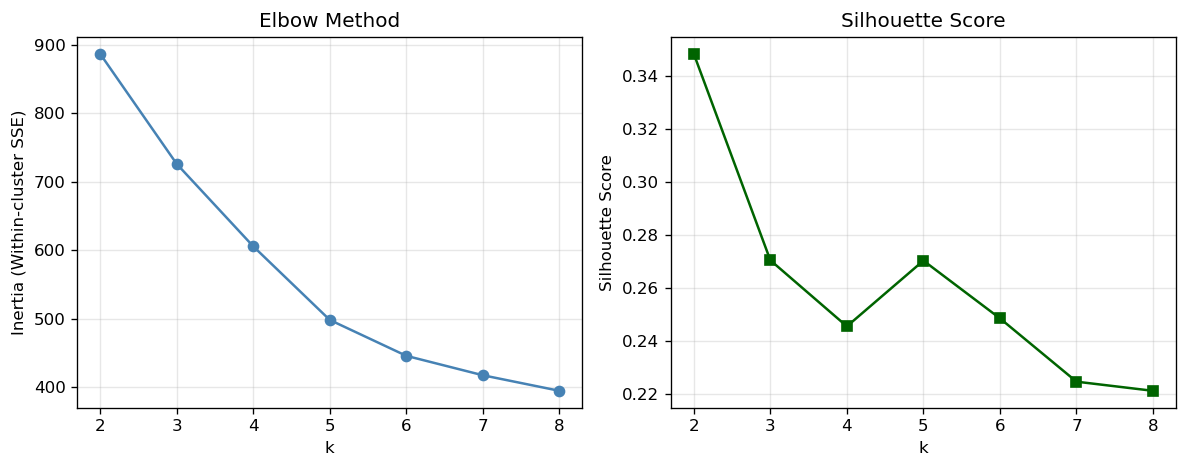

Best k by silhouette: 2  (score=0.348)


In [31]:
# --- 2.1  Prepare clustering features -------------------------------------------
CLUSTER_VARS = [
    'pct_poor_health', 'pct_low_nssec', 'pct_high_nssec',
    'pct_elderly_alone', 'pct_dep_children', 'pct_lone_parent',
    'pct_long_commute', 'pct_large_hh', 'pct_deprived_2plus'
]

X_demo = master[CLUSTER_VARS].fillna(0).values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_demo)

# --- 2.2  Elbow + Silhouette to choose k ------------------------------------
inertias, sil_scores = [], []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(list(K_range), inertias, 'o-', color='steelblue')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia (Within-cluster SSE)')
axes[0].set_title('Elbow Method')
axes[1].plot(list(K_range), sil_scores, 's-', color='darkgreen')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score')
for ax in axes:
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'pop_cluster_elbow.png'), dpi=150, bbox_inches='tight')
plt.show()

best_k = sil_scores.index(max(sil_scores)) + 2
print(f'Best k by silhouette: {best_k}  (score={max(sil_scores):.3f})')

In [32]:
# --- 2.3  Final K-means clustering -------------------------------------------
K_FINAL = 4  # Set to 4 to match HEI quintile groupings; override if elbow differs

km_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init=30)
master['pop_cluster'] = km_final.fit_predict(X_scaled).astype(str)

# Label clusters by dominant characteristic
cluster_means = master.groupby('pop_cluster')[CLUSTER_VARS].mean()
print('Cluster means (standardised):')
print(cluster_means.round(3))

# Auto-label by dominant variable
LABELS = {
    'high_deprivation':  'D',  # high pct_deprived_2plus + pct_low_nssec
    'elderly_single':    'E',  # high pct_elderly_alone
    'families_children': 'F',  # high pct_dep_children + pct_large_hh
    'commuter_worker':   'C',  # high pct_high_nssec + pct_long_commute
}

# Rank clusters by each key indicator and assign label
_key_vars = ['pct_deprived_2plus', 'pct_elderly_alone', 'pct_dep_children', 'pct_high_nssec']
_assigned = {}
_used = set()
for var, label in zip(_key_vars, ['Deprived', 'Elderly', 'Family', 'Professional']):
    best = cluster_means[var].idxmax()
    if best not in _used:
        _assigned[best] = label
        _used.add(best)

# Fill unassigned
for c in cluster_means.index:
    if c not in _assigned:
        _assigned[c] = f'Mixed_{c}'

master['pop_label'] = master['pop_cluster'].map(_assigned)
print('\nCluster labels:', _assigned)
print(master['pop_label'].value_counts())

Cluster means (standardised):
             pct_poor_health  pct_low_nssec  pct_high_nssec  \
pop_cluster                                                   
0                      0.045          0.274           0.407   
1                      0.020          0.115           0.604   
2                      0.051          0.370           0.290   
3                      0.033          0.168           0.565   

             pct_elderly_alone  pct_dep_children  pct_lone_parent  \
pop_cluster                                                         
0                        0.072             0.222            0.091   
1                        0.040             0.136            0.039   
2                        0.084             0.304            0.137   
3                        0.083             0.306            0.059   

             pct_long_commute  pct_large_hh  pct_deprived_2plus  
pop_cluster                                                      
0                       0.021         0.063 

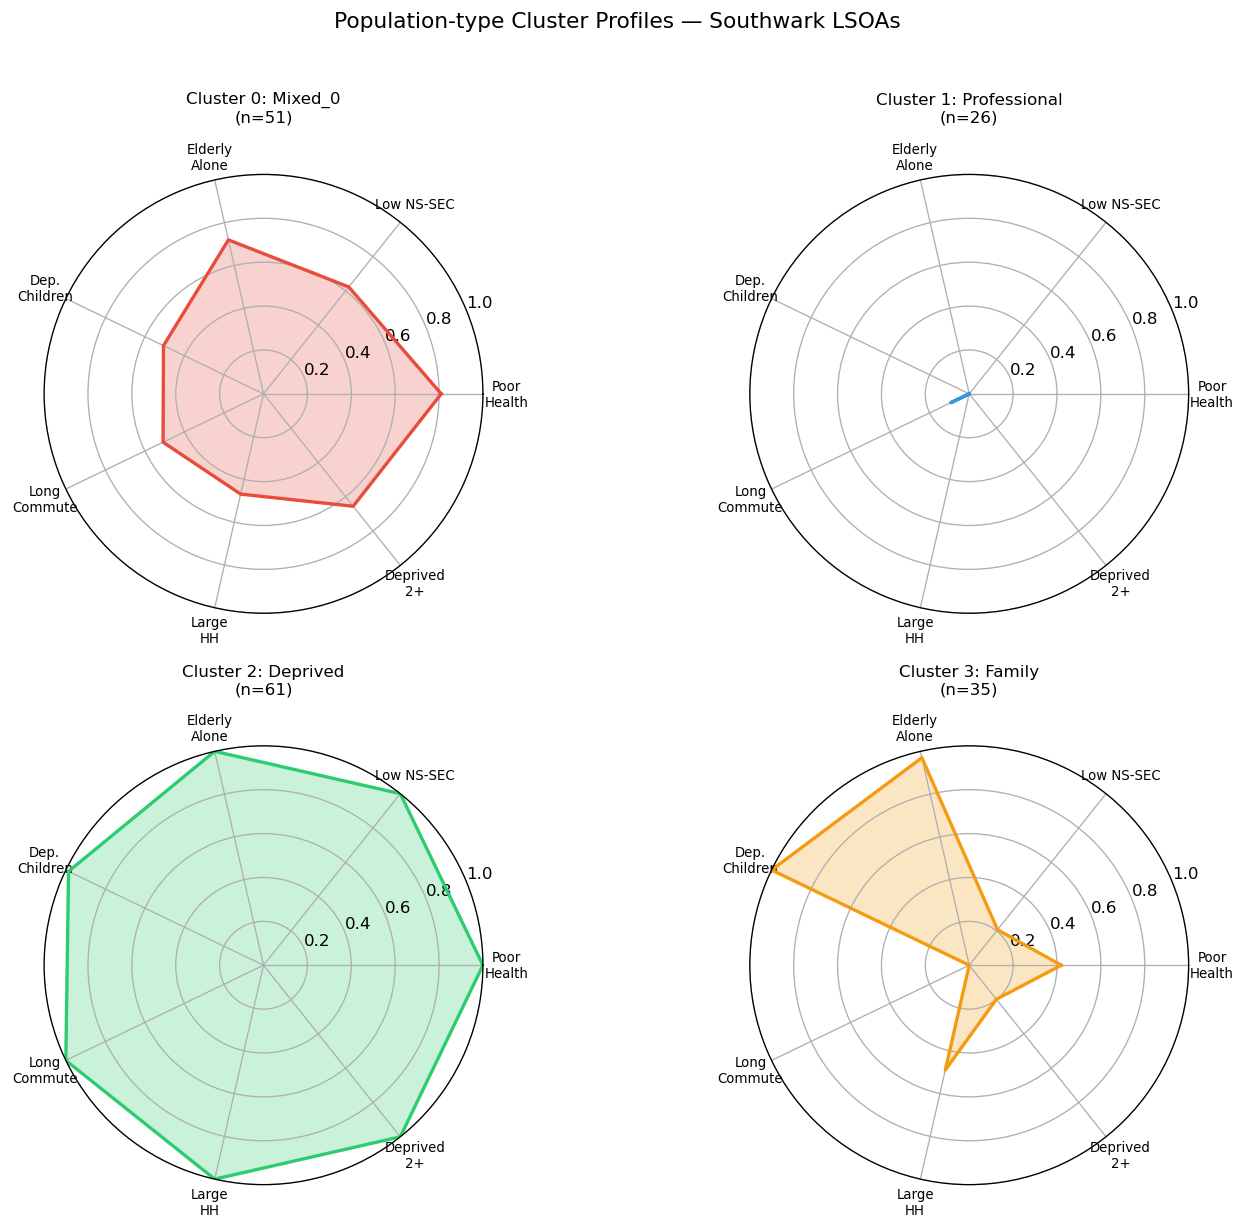

In [33]:
# --- 2.4  Radar profile chart ------------------------------------------------
from matplotlib.patches import FancyArrowPatch

fig, axes = plt.subplots(2, 2, figsize=(12, 10), subplot_kw=dict(polar=True))
axes = axes.flatten()

PLOT_VARS = ['pct_poor_health', 'pct_low_nssec', 'pct_elderly_alone',
             'pct_dep_children', 'pct_long_commute', 'pct_large_hh', 'pct_deprived_2plus']
LABELS_RADAR = ['Poor\nHealth', 'Low NS-SEC', 'Elderly\nAlone',
                 'Dep.\nChildren', 'Long\nCommute', 'Large\nHH', 'Deprived\n2+']
N = len(PLOT_VARS)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

COLORS = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

# Normalise to [0,1] for radar
_mm = lambda x: (x - x.min()) / (x.max() - x.min() + 1e-9)
norm_means = cluster_means[PLOT_VARS].apply(_mm, axis=0)

for idx, (cluster_id, row) in enumerate(norm_means.iterrows()):
    ax = axes[idx]
    values = row.tolist() + row.tolist()[:1]
    label_name = _assigned.get(cluster_id, f'C{cluster_id}')
    ax.plot(angles, values, color=COLORS[idx], linewidth=2)
    ax.fill(angles, values, color=COLORS[idx], alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(LABELS_RADAR, size=8)
    ax.set_ylim(0, 1)
    ax.set_title(f'Cluster {cluster_id}: {label_name}\n(n={master[master["pop_cluster"]==cluster_id].shape[0]})',
                 size=10, pad=12)

plt.suptitle('Population-type Cluster Profiles — Southwark LSOAs', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'pop_cluster_radar.png'), dpi=150, bbox_inches='tight')
plt.show()

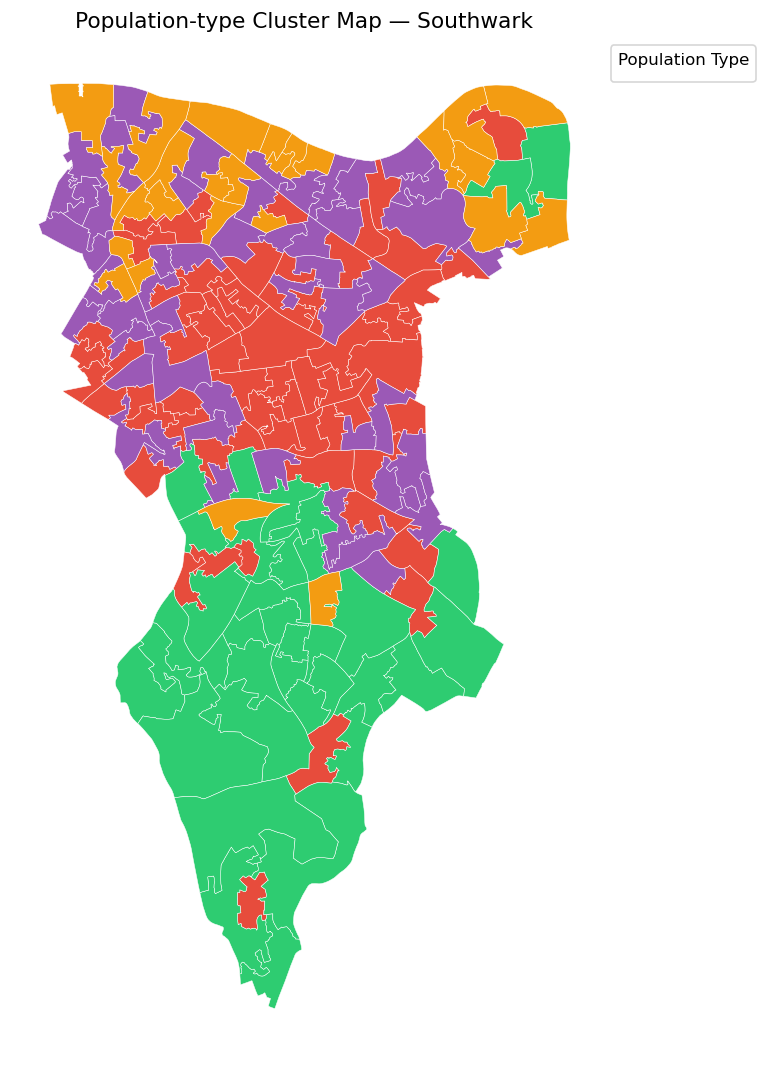

pop_label
Deprived        61
Mixed_0         51
Family          35
Professional    26


In [34]:
# --- 2.5  Cluster spatial map ------------------------------------------------
geo_pop = geo_swk.merge(master[['lsoa21cd', 'pop_cluster', 'pop_label']].drop_duplicates(),
                         left_on=geo_col, right_on='lsoa21cd', how='left')

CMAP_POP = {'Deprived': '#e74c3c', 'Elderly': '#3498db',
             'Family': '#2ecc71', 'Professional': '#f39c12'}
# fallback for mixed
for lbl in geo_pop['pop_label'].unique():
    if lbl not in CMAP_POP and pd.notna(lbl):
        CMAP_POP[lbl] = '#9b59b6'

fig, ax = plt.subplots(figsize=(9, 9))
for lbl, grp in geo_pop.groupby('pop_label'):
    grp.plot(ax=ax, color=CMAP_POP.get(lbl, '#aaaaaa'), label=lbl, edgecolor='white', linewidth=0.3)
ax.legend(title='Population Type', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.set_title('Population-type Cluster Map — Southwark', fontsize=13)
ax.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'pop_cluster_map.png'), dpi=150, bbox_inches='tight')
plt.show()

print(master['pop_label'].value_counts().to_string())

## Section 3 — H1: Objective Deprivation Stress Test (One-way ANOVA + Tukey HSD)

**H1 test logic**: Group LSOAs by `HEI_quintile` (Q1 best → Q5 worst) and test whether demographic vulnerability indicators (low NS-SEC share, household deprivation rate, share with dependent children, elderly alone) differ significantly across quintiles.

Significant result → deprived housing areas disproportionately contain vulnerable populations, confirming H1.

In [35]:
# --- 3.1  One-way ANOVA: demographic indicators across HEI quintile ---------
TEST_VARS = {
    'pct_low_nssec':      'Low NS-SEC share (semi-routine/routine/unemployed)',
    'pct_high_nssec':     'High NS-SEC share (higher/lower managerial & professional)',
    'pct_poor_health':    'Poor health share (bad/very bad)',
    'pct_deprived_2plus': 'Multi-dimensional deprivation (≥2 dimensions)',
    'pct_dep_children':   'Share of households with dependent children',
    'pct_elderly_alone':  'Elderly living alone share',
    'pct_lone_parent':    'Lone parent share',
    'pct_large_hh':       'Large household share (≥5 persons)',
    'pct_long_commute':   'Long-distance commute share (≥20 km)',
}

quintile_order = ['Q1 (best)', 'Q2', 'Q3', 'Q4', 'Q5 (worst)']
anova_results = []

for var, label in TEST_VARS.items():
    groups = [master.loc[master['HEI_quintile'] == q, var].dropna().values
              for q in quintile_order]
    f_stat, p_val = f_oneway(*groups)
    anova_results.append({
        'variable': var, 'label': label,
        'F': round(f_stat, 3), 'p_value': round(p_val, 4),
        'sig': '***' if p_val < 0.001 else ('**' if p_val < 0.01 else ('*' if p_val < 0.05 else 'ns'))
    })

anova_df = pd.DataFrame(anova_results).sort_values('p_value')
print('ANOVA Results: Demographic Variables across HEI Quintiles')
print('=' * 75)
print(anova_df.to_string(index=False))

ANOVA Results: Demographic Variables across HEI Quintiles
          variable                                                      label     F  p_value sig
 pct_elderly_alone                                 Elderly living alone share 1.416   0.2309  ns
   pct_poor_health                           Poor health share (bad/very bad) 1.409   0.2332  ns
  pct_long_commute                       Long-distance commute share (≥20 km) 1.042   0.3871  ns
pct_deprived_2plus              Multi-dimensional deprivation (≥2 dimensions) 0.960   0.4312  ns
    pct_high_nssec High NS-SEC share (higher/lower managerial & professional) 0.955   0.4337  ns
  pct_dep_children                Share of households with dependent children 0.948   0.4378  ns
     pct_low_nssec         Low NS-SEC share (semi-routine/routine/unemployed) 0.752   0.5583  ns
   pct_lone_parent                                          Lone parent share 0.284   0.8878  ns
      pct_large_hh                         Large household share (≥5 

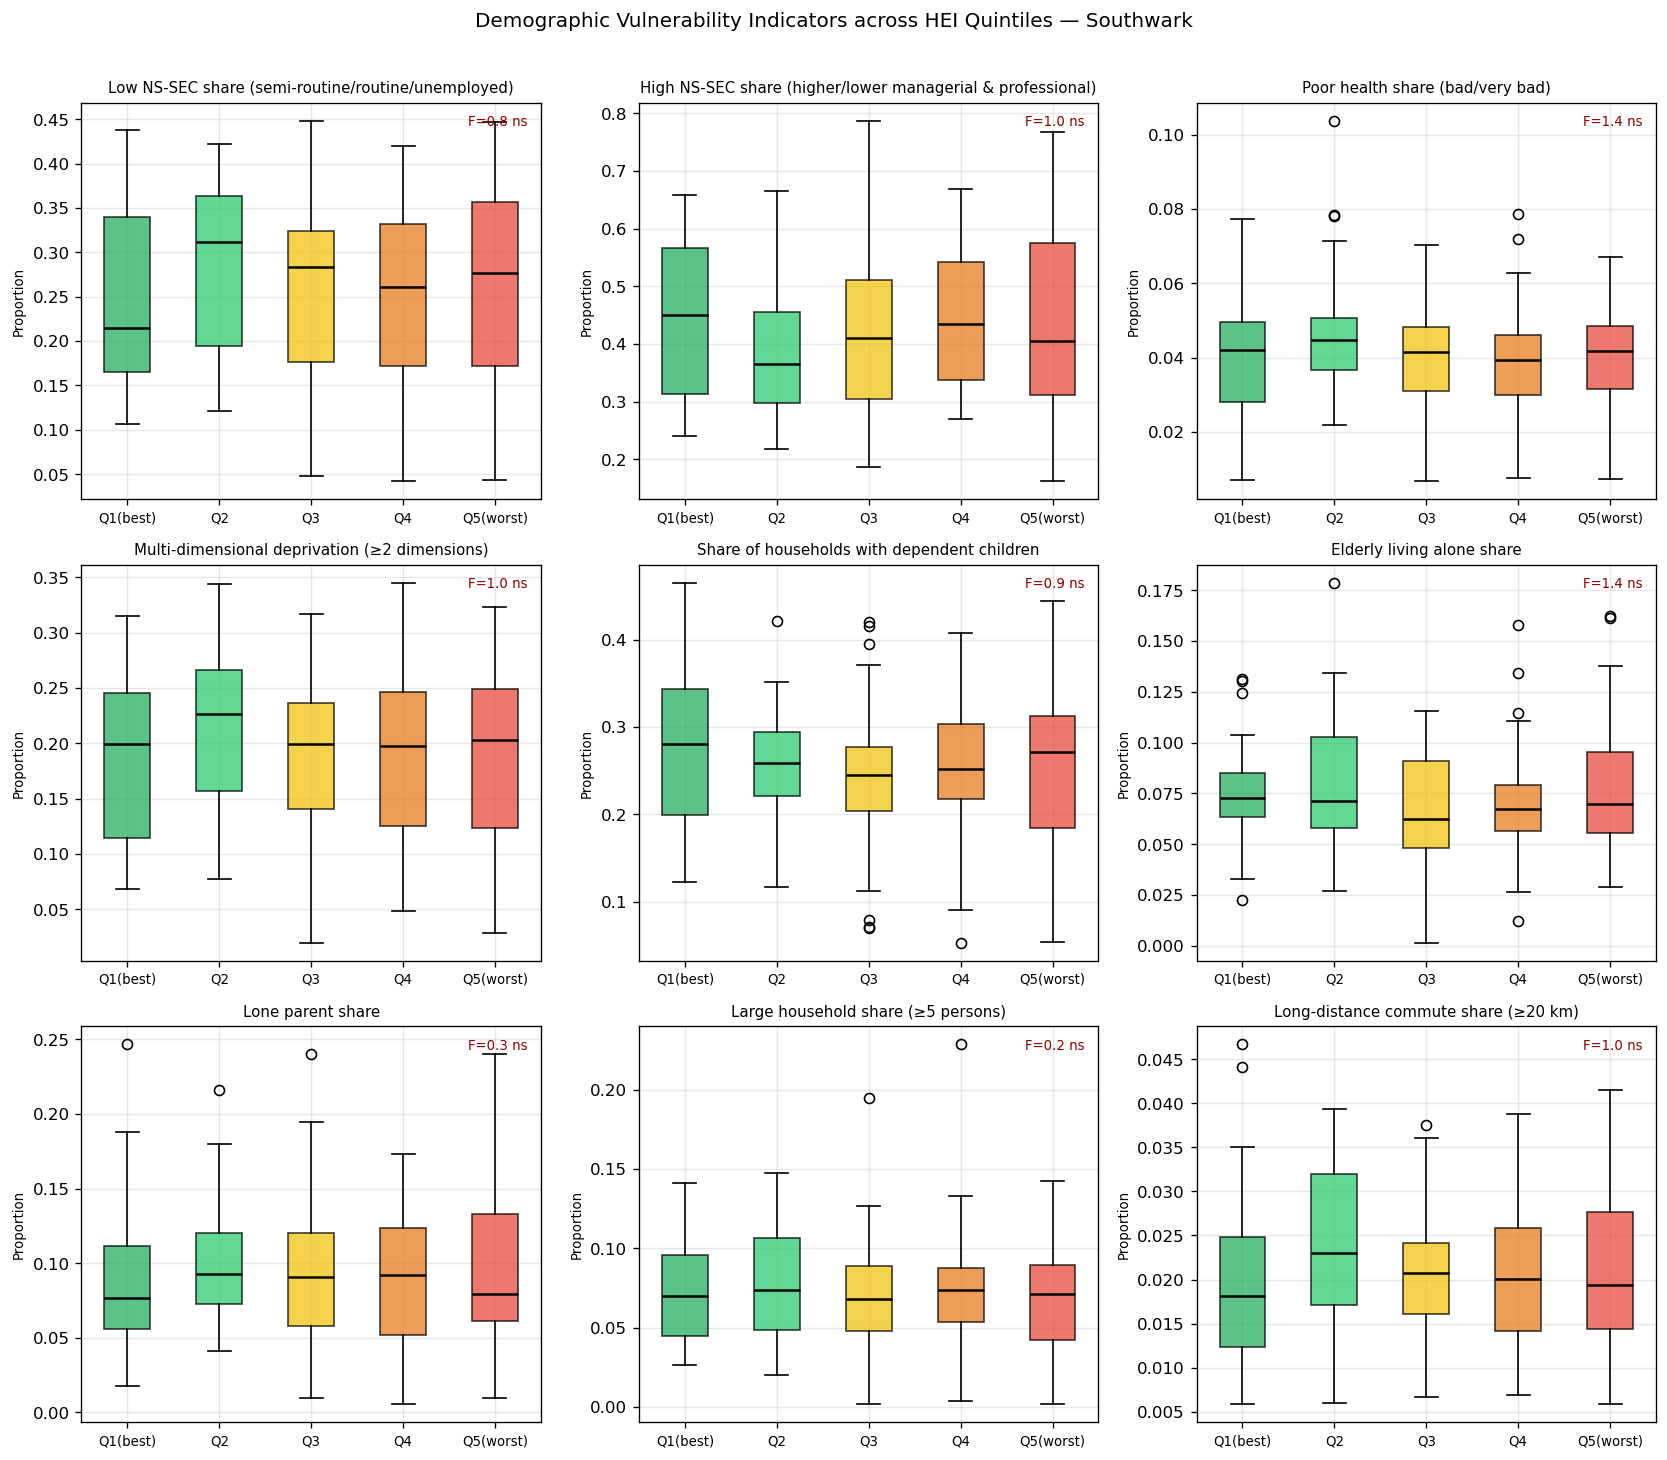

In [36]:
# --- 3.2  Grouped box plots: key variables across HEI quintile --------------
sig_vars = [r['variable'] for r in anova_results if r['p_value'] < 0.05]
n_sig = len(sig_vars)

fig, axes = plt.subplots(3, 3, figsize=(14, 12))
axes = axes.flatten()

QUINTLE_COLORS = ['#27ae60', '#2ecc71', '#f1c40f', '#e67e22', '#e74c3c']

for i, (var, label) in enumerate(TEST_VARS.items()):
    ax = axes[i]
    data_by_q = [master.loc[master['HEI_quintile'] == q, var].dropna().values
                 for q in quintile_order]
    bp = ax.boxplot(data_by_q, patch_artist=True, notch=False,
                    medianprops=dict(color='black', linewidth=1.5))
    for patch, color in zip(bp['boxes'], QUINTLE_COLORS):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
    ax.set_xticklabels(['Q1(best)', 'Q2', 'Q3', 'Q4', 'Q5(worst)'], fontsize=8)
    ax.set_title(label, fontsize=9)
    ax.set_ylabel('Proportion', fontsize=8)
    ax.grid(alpha=0.3)
    # Add significance label
    r = next(x for x in anova_results if x['variable'] == var)
    ax.text(0.97, 0.97, f"F={r['F']:.1f} {r['sig']}", transform=ax.transAxes,
            ha='right', va='top', fontsize=8, color='darkred')

plt.suptitle('Demographic Vulnerability Indicators across HEI Quintiles — Southwark', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'h1_anova_boxplots.png'), dpi=150, bbox_inches='tight')
plt.show()

In [37]:
# --- 3.3  Tukey HSD post-hoc for significant variables ----------------------
from statsmodels.stats.multicomp import pairwise_tukeyhsd

print('Tukey HSD Post-hoc Tests (p < 0.05 variables only)')
print('=' * 60)

for var, label in TEST_VARS.items():
    r = next(x for x in anova_results if x['variable'] == var)
    if r['p_value'] >= 0.05:
        continue
    sub = master[['HEI_quintile', var]].dropna()
    tukey = pairwise_tukeyhsd(sub[var], sub['HEI_quintile'], alpha=0.05)
    sig_pairs = [(str(r._asdict()['group1']), str(r._asdict()['group2']))
                 for r in tukey._results_table[1:]
                 if float(str(r._asdict()['reject'])) or str(r._asdict()['reject']) == 'True']
    print(f'\n{label} (F={r["F"]}, p={r["p_value"]}):')
    if sig_pairs:
        for g1, g2 in sig_pairs:
            print(f'  {g1} vs {g2}: significant')
    else:
        print('  No pairwise significant differences at α=0.05')

Tukey HSD Post-hoc Tests (p < 0.05 variables only)


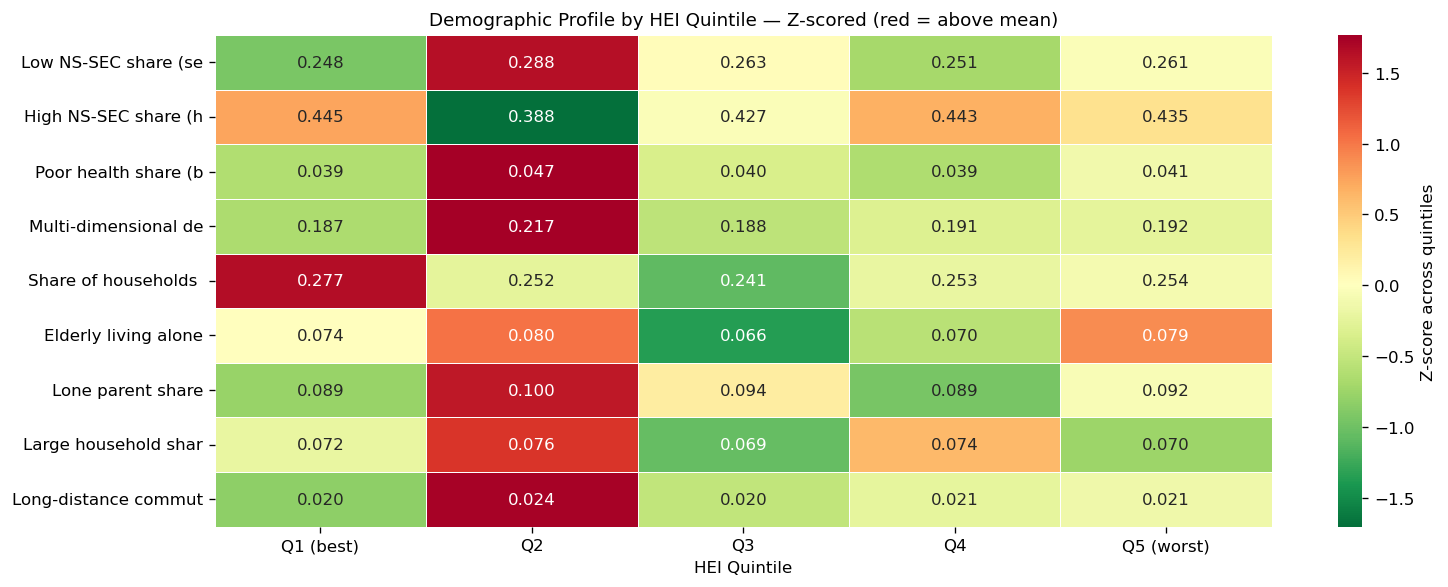

In [38]:
# --- 3.4  Mean values heatmap by HEI quintile --------------------------------
pivot_means = master.groupby('HEI_quintile')[list(TEST_VARS.keys())].mean().reindex(quintile_order)
pivot_means.columns = [TEST_VARS[c][:20] for c in pivot_means.columns]

# Z-score across quintiles for comparison
pivot_z = pivot_means.apply(lambda col: (col - col.mean()) / col.std(), axis=0)

fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(pivot_z.T, annot=pivot_means.T.round(3), fmt='.3f',
            cmap='RdYlGn_r', center=0, ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Z-score across quintiles'})
ax.set_title('Demographic Profile by HEI Quintile — Z-scored (red = above mean)', fontsize=11)
ax.set_xlabel('HEI Quintile'); ax.set_ylabel('')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'h1_heatmap_quintile.png'), dpi=150, bbox_inches='tight')
plt.show()

## Section 4 — H2: Perceived Sensitivity Divergence (Kruskal-Wallis + Correlation Matrix)

**H2 test logic**: Test Spearman correlations between specific demographic proportions (elderly alone, families with children, low NS-SEC, long commuters) and corresponding HEI sub-dimensions (hospital access, overcrowding, house prices, transport), to assess whether different population types show concentrated exposure to specific housing deficits.

**Hypotheses**:
- Elderly alone ↔ hospital access (elderly more sensitive to healthcare)
- Families with children / large HH ↔ overcrowding
- Long commuters ↔ transport accessibility (PTAI)
- Low NS-SEC ↔ median house price (greater affordability burden)

In [39]:
# --- 4.1  Spearman correlation: demographic ↔ HEI components ----------------
SENSITIVITY_PAIRS = {
    'pct_elderly_alone':  ('hospital',            'Elderly alone x Hospital access'),
    'pct_dep_children':   ('overcrowding_proxy',  'Households w/ children x Overcrowding'),
    'pct_large_hh':       ('overcrowding_proxy',  'Large HH x Overcrowding'),
    'pct_low_nssec':      ('median_house_price',  'Low NS-SEC x House price'),
    'pct_long_commute':   ('transport_ptai',      'Long commute x Transport (PTAI)'),
    'pct_poor_health':    ('avg_epc_rating_num',  'Poor health x EPC rating'),
    'pct_lone_parent':    ('overcrowding_proxy',  'Lone parent x Overcrowding'),
    'pct_deprived_2plus': ('HEI_bayes',           'Multi-dim. deprivation x Overall HEI'),
}

sens_results = []
for demo_var, (hei_var, label) in SENSITIVITY_PAIRS.items():
    sub = master[[demo_var, hei_var]].dropna()
    rho, pval = spearmanr(sub[demo_var], sub[hei_var])
    sens_results.append({
        'demo_var': demo_var, 'hei_component': hei_var, 'label': label,
        'rho': round(rho, 3), 'p_value': round(pval, 4),
        'sig': '***' if pval < 0.001 else ('**' if pval < 0.01 else ('*' if pval < 0.05 else 'ns'))
    })

sens_df = pd.DataFrame(sens_results)
print('Spearman Correlations: Demographic x HEI Component')
print('=' * 70)
print(sens_df[['label', 'rho', 'p_value', 'sig']].to_string(index=False))

Spearman Correlations: Demographic x HEI Component
                                label    rho  p_value sig
      Elderly alone x Hospital access  0.073   0.3400  ns
Households w/ children x Overcrowding -0.222   0.0034  **
              Large HH x Overcrowding -0.004   0.9540  ns
             Low NS-SEC x House price -0.655   0.0000 ***
      Long commute x Transport (PTAI)  0.007   0.9296  ns
             Poor health x EPC rating  0.197   0.0094  **
           Lone parent x Overcrowding  0.434   0.0000 ***
 Multi-dim. deprivation x Overall HEI -0.014   0.8527  ns


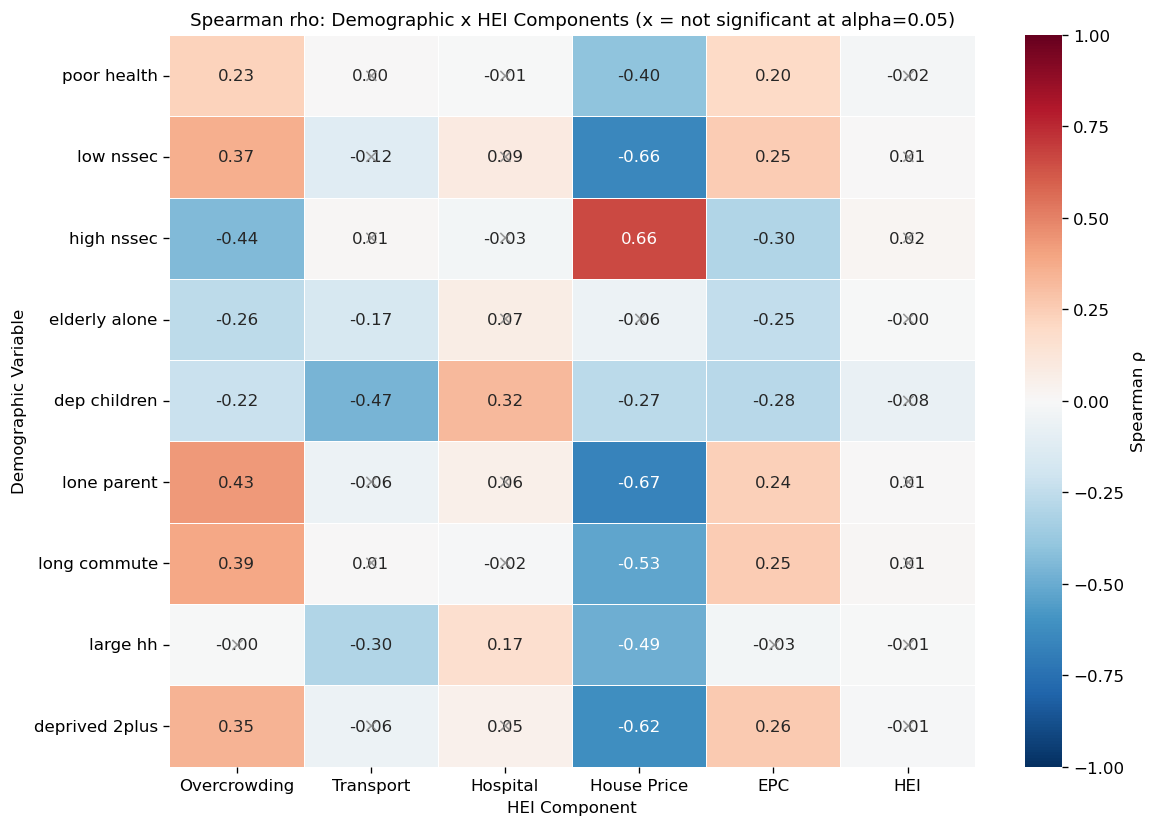

In [40]:
# --- 4.2  Full correlation heatmap: all demographics × all HEI components ---
DEMO_PLOT = ['pct_poor_health', 'pct_low_nssec', 'pct_high_nssec',
             'pct_elderly_alone', 'pct_dep_children', 'pct_lone_parent',
             'pct_long_commute', 'pct_large_hh', 'pct_deprived_2plus']
HEI_PLOT  = ['overcrowding_proxy', 'transport_ptai', 'hospital',
              'median_house_price', 'avg_epc_rating_num', 'HEI_bayes']

corr_mat = np.zeros((len(DEMO_PLOT), len(HEI_PLOT)))
pval_mat = np.zeros_like(corr_mat)

for i, dv in enumerate(DEMO_PLOT):
    for j, hv in enumerate(HEI_PLOT):
        sub = master[[dv, hv]].dropna()
        rho, pval = spearmanr(sub[dv], sub[hv])
        corr_mat[i, j] = rho
        pval_mat[i, j] = pval

corr_df = pd.DataFrame(corr_mat,
    index=[c.replace('pct_', '').replace('_', ' ') for c in DEMO_PLOT],
    columns=['Overcrowding', 'Transport', 'Hospital', 'House Price', 'EPC', 'HEI'])

fig, ax = plt.subplots(figsize=(10, 7))
mask_insig = pval_mat >= 0.05
sns.heatmap(corr_df, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, ax=ax, linewidths=0.4,
            cbar_kws={'label': 'Spearman ρ'})

# Cross out insignificant cells
for i in range(len(DEMO_PLOT)):
    for j in range(len(HEI_PLOT)):
        if pval_mat[i, j] >= 0.05:
            ax.text(j + 0.5, i + 0.5, '×', ha='center', va='center',
                    fontsize=12, color='grey', alpha=0.8)

ax.set_title('Spearman rho: Demographic x HEI Components (x = not significant at alpha=0.05)',
             fontsize=11)
ax.set_xlabel('HEI Component'); ax.set_ylabel('Demographic Variable')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'h2_sensitivity_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

In [41]:
# --- 4.3  Kruskal-Wallis: HEI components across population clusters ----------
print('Kruskal-Wallis Tests: HEI Components across Population-type Clusters')
print('=' * 70)

kw_results = []
for comp in HEI_COMPONENTS:
    groups = [master.loc[master['pop_label'] == lbl, comp].dropna().values
              for lbl in master['pop_label'].dropna().unique()]
    h_stat, p_val = kruskal(*groups)
    kw_results.append({'HEI Component': comp, 'H': round(h_stat, 3),
                       'p_value': round(p_val, 4),
                       'sig': '***' if p_val < 0.001 else ('**' if p_val < 0.01 else ('*' if p_val < 0.05 else 'ns'))})

kw_df = pd.DataFrame(kw_results)
print(kw_df.to_string(index=False))

Kruskal-Wallis Tests: HEI Components across Population-type Clusters
     HEI Component      H  p_value sig
overcrowding_proxy 73.323   0.0000 ***
    transport_ptai 32.565   0.0000 ***
          hospital 10.295   0.0162   *
median_house_price 71.129   0.0000 ***
avg_epc_rating_num 69.351   0.0000 ***


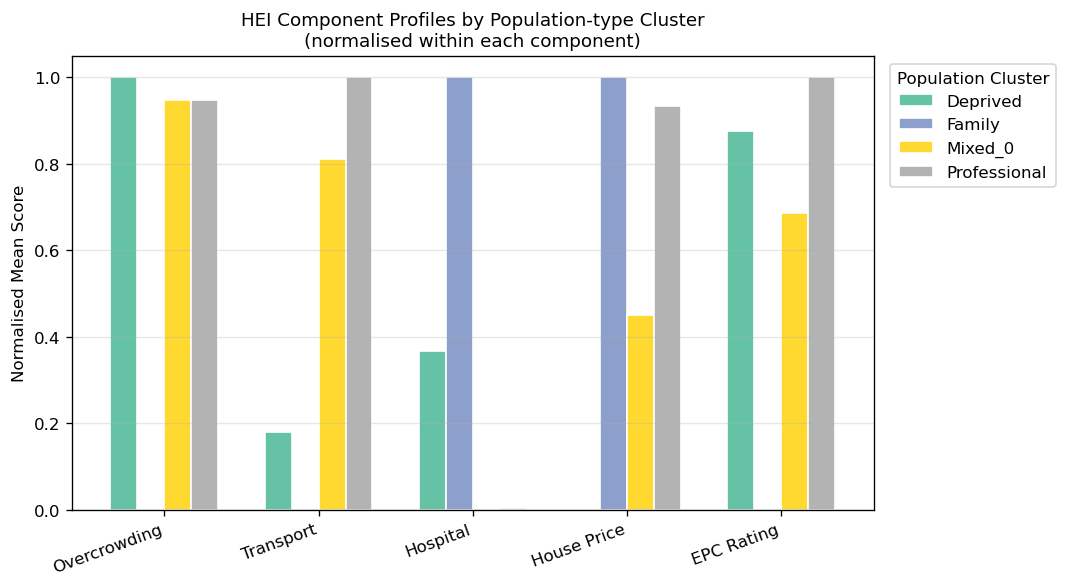

In [42]:
# --- 4.4  Sensitivity profile: mean HEI component by population cluster ------
comp_labels = {'overcrowding_proxy': 'Overcrowding', 'transport_ptai': 'Transport',
               'hospital': 'Hospital', 'median_house_price': 'House Price',
               'avg_epc_rating_num': 'EPC Rating'}

cluster_comp = master.groupby('pop_label')[HEI_COMPONENTS].mean()
# Normalise columns to [0,1] for visibility
cluster_comp_norm = cluster_comp.apply(lambda c: (c - c.min()) / (c.max() - c.min() + 1e-9), axis=0)
cluster_comp_norm.columns = [comp_labels[c] for c in cluster_comp_norm.columns]

fig, ax = plt.subplots(figsize=(9, 5))
cluster_comp_norm.T.plot(kind='bar', ax=ax, colormap='Set2', edgecolor='white', width=0.7)
ax.set_ylabel('Normalised Mean Score')
ax.set_title('HEI Component Profiles by Population-type Cluster\n(normalised within each component)',
             fontsize=11)
ax.legend(title='Population Cluster', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'h2_cluster_sensitivity.png'), dpi=150, bbox_inches='tight')
plt.show()

## Section 5 — H3: Spatial Double-Deprivation Pattern (GIS Overlay + Chi-square)

**H3 test logic**:
1. **Chi-square test**: independence of `HEI_quintile` × `pop_cluster`
2. **Double deprivation**: Q5 (worst HEI) + Deprived population cluster
3. **Double advantage**: Q1 (best HEI) + Professional population cluster
4. **GIS overlay map**: visualise four zone types (Double Deprivation / Double Advantage / Housing Deprived / Housing Advantaged)

Cross-tabulation: HEI Quintile x Population Cluster
pop_label     Deprived  Family  Mixed_0  Professional
HEI_quintile                                         
Q1 (best)           11      10        6             5
Q2                  15       5       10             4
Q3                  12       6       16             8
Q4                  10       7       10             4
Q5 (worst)          13       7        9             5
Chi-square: chi2=8.004, df=12, p=0.7849
→ No significant association ✗


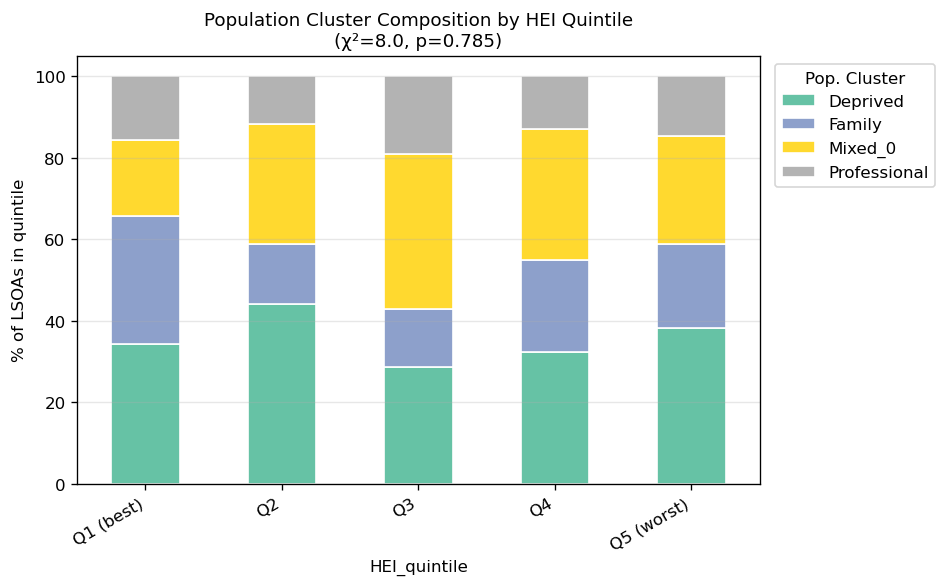

In [43]:
# --- 5.1  Chi-square: HEI_quintile × Population cluster ----------------------
ct = pd.crosstab(master['HEI_quintile'], master['pop_label'])
chi2, p_chi2, dof, expected = chi2_contingency(ct)

print('Cross-tabulation: HEI Quintile x Population Cluster')
print(ct.to_string())
print(f'Chi-square: chi2={chi2:.3f}, df={dof}, p={p_chi2:.4f}')
print('→', 'Significant association ✓' if p_chi2 < 0.05 else 'No significant association ✗')

fig, ax = plt.subplots(figsize=(8, 5))
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
ct_pct.reindex(quintile_order).plot(kind='bar', stacked=True, ax=ax,
                                     colormap='Set2', edgecolor='white')
ax.set_ylabel('% of LSOAs in quintile')
ax.set_title(f'Population Cluster Composition by HEI Quintile\n(χ²={chi2:.1f}, p={p_chi2:.3f})',
             fontsize=11)
ax.legend(title='Pop. Cluster', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'h3_chi2_stacked.png'), dpi=150, bbox_inches='tight')
plt.show()

In [44]:
# --- 5.2  Identify double-deprivation / double-advantage zones ---------------
# Double deprivation: Q5 (worst HEI) + Deprived population cluster
# Double advantage:   Q1 (best HEI)  + Professional population cluster

depriv_cluster  = master['pop_label'].value_counts().idxmax()   # most common = largest cluster
# Override: use 'Deprived' and 'Professional' if they exist
if 'Deprived' in master['pop_label'].values:
    depriv_cluster = 'Deprived'
if 'Professional' in master['pop_label'].values:
    adv_cluster = 'Professional'
else:
    # Fallback: cluster with lowest pct_low_nssec
    adv_cluster = master.groupby('pop_label')['pct_low_nssec'].mean().idxmin()

def classify_zone(row):
    q = row['HEI_quintile']
    c = row['pop_label']
    if q == 'Q5 (worst)' and c == depriv_cluster:
        return 'Double Deprivation'
    elif q == 'Q1 (best)' and c == adv_cluster:
        return 'Double Advantage'
    elif q in ['Q4', 'Q5 (worst)']:
        return 'Housing Deprived'
    elif q in ['Q1 (best)', 'Q2']:
        return 'Housing Advantaged'
    else:
        return 'Mixed'

master['zone_type'] = master.apply(classify_zone, axis=1)
print('Zone classification:')
print(master['zone_type'].value_counts())
print(f'\nDouble deprivation cluster: {depriv_cluster}')
print(f'Double advantage cluster: {adv_cluster}')

Zone classification:
zone_type
Housing Advantaged    61
Housing Deprived      52
Mixed                 42
Double Deprivation    13
Double Advantage       5
Name: count, dtype: int64

Double deprivation cluster: Deprived
Double advantage cluster: Professional


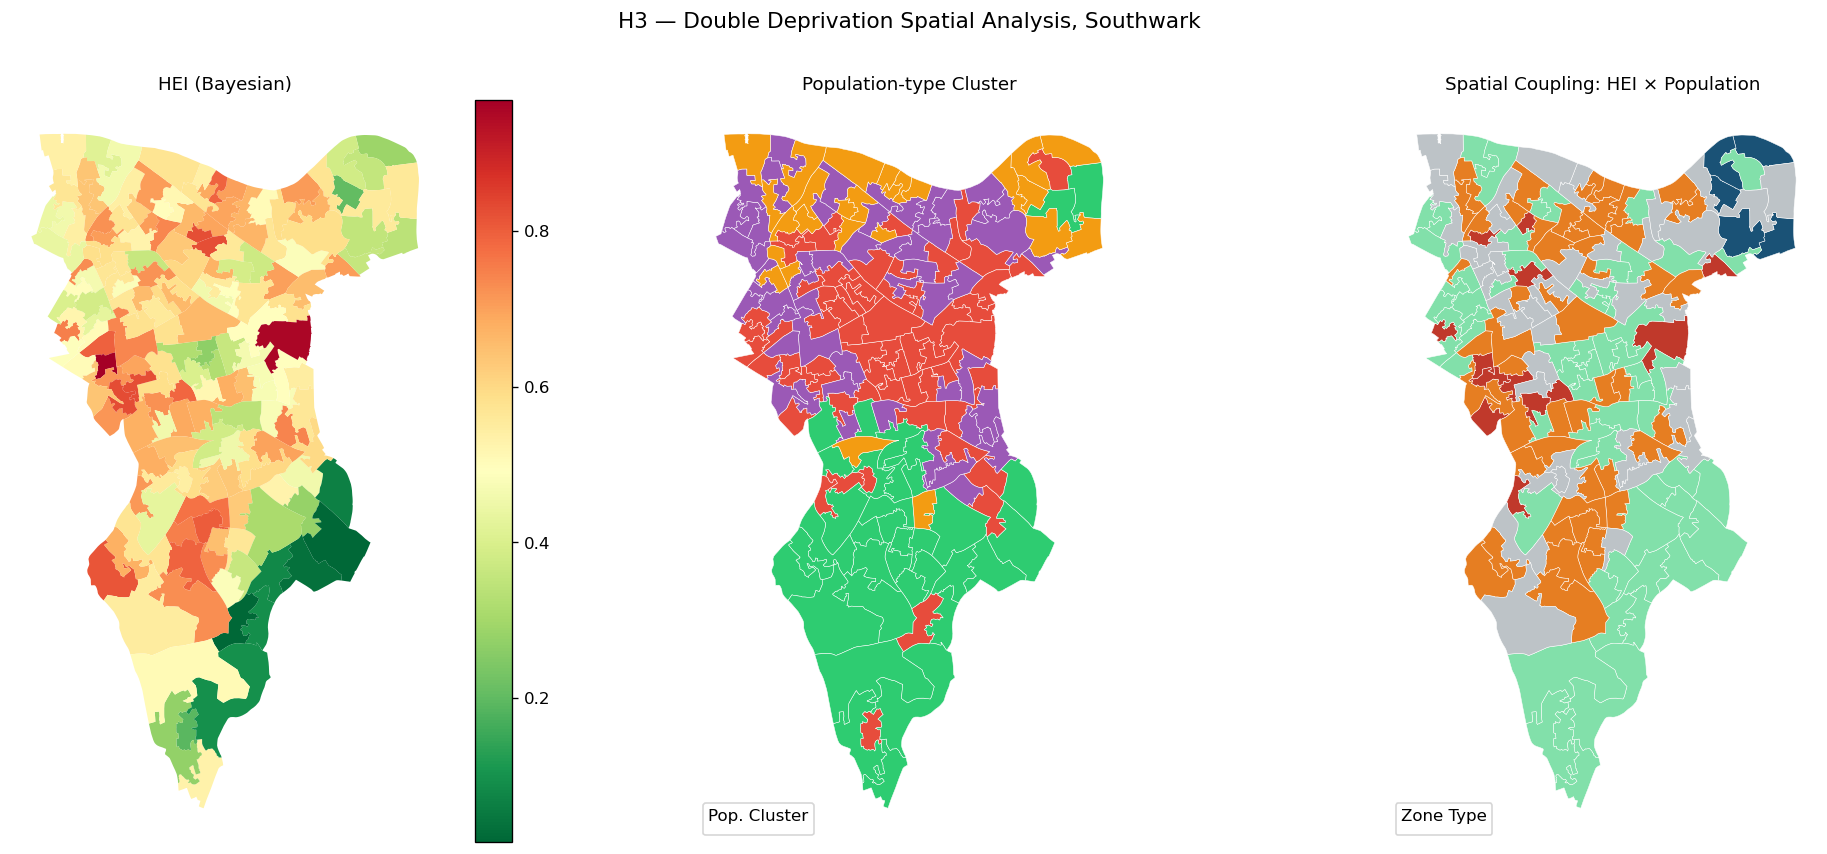

In [45]:
# --- 5.3  Spatial map: double deprivation overlay ----------------------------
ZONE_COLORS = {
    'Double Deprivation': '#c0392b',
    'Housing Deprived':   '#e67e22',
    'Mixed':              '#bdc3c7',
    'Housing Advantaged': '#82e0aa',
    'Double Advantage':   '#1a5276',
}

geo_zone = geo_swk.merge(
    master[['lsoa21cd', 'zone_type', 'HEI_quintile', 'pop_label']].drop_duplicates('lsoa21cd'),
    left_on=geo_col, right_on='lsoa21cd', how='left')
geo_zone['zone_type'] = geo_zone['zone_type'].fillna('Mixed')

fig, axes = plt.subplots(1, 3, figsize=(18, 7))

# Panel 1: HEI Quintile
geo_hei_plot = geo_swk.merge(
    master[['lsoa21cd', 'HEI_bayes']].drop_duplicates('lsoa21cd'),
    left_on=geo_col, right_on='lsoa21cd', how='left')
geo_hei_plot.plot(column='HEI_bayes', cmap='RdYlGn_r', legend=True, ax=axes[0],
                   missing_kwds={'color': 'lightgrey'})
axes[0].set_title('HEI (Bayesian)', fontsize=11); axes[0].axis('off')

# Panel 2: Population cluster
for lbl, grp in geo_zone.groupby('pop_label'):
    grp.plot(ax=axes[1], color=CMAP_POP.get(lbl, '#aaaaaa'), label=lbl,
             edgecolor='white', linewidth=0.3)
axes[1].legend(title='Pop. Cluster', fontsize=8, loc='lower left')
axes[1].set_title('Population-type Cluster', fontsize=11); axes[1].axis('off')

# Panel 3: Zone overlay
for zone, grp in geo_zone.groupby('zone_type'):
    grp.plot(ax=axes[2], color=ZONE_COLORS.get(zone, '#cccccc'), label=zone,
             edgecolor='white', linewidth=0.3)
axes[2].legend(title='Zone Type', fontsize=8, loc='lower left')
axes[2].set_title('Spatial Coupling: HEI × Population', fontsize=11); axes[2].axis('off')

plt.suptitle('H3 — Double Deprivation Spatial Analysis, Southwark', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'h3_double_deprivation_map.png'), dpi=150, bbox_inches='tight')
plt.show()

In [46]:
# --- 5.4  Bivariate Moran's I: HEI_bayes × pct_deprived_2plus ---------------
try:
    import libpysal
    from esda.moran import Moran_BV

    # Build spatial weights
    geo_moran = geo_swk.merge(
        master[['lsoa21cd', 'HEI_bayes', 'pct_deprived_2plus']].drop_duplicates('lsoa21cd'),
        left_on=geo_col, right_on='lsoa21cd', how='left').dropna(
            subset=['HEI_bayes', 'pct_deprived_2plus'])

    w = libpysal.weights.Queen.from_dataframe(geo_moran, silence_warnings=True)
    w.transform = 'r'

    bv = Moran_BV(geo_moran['HEI_bayes'].values,
                  geo_moran['pct_deprived_2plus'].values, w, permutations=999)
    print(f'Bivariate Moran\'s I (HEI_bayes × pct_deprived_2plus):')
    print(f'  I = {bv.I:.4f}  |  p-value (permutation) = {bv.p_sim:.4f}')
    print('→', 'Significant spatial co-clustering ✓' if bv.p_sim < 0.05 else 'No significant spatial co-clustering')

except ImportError:
    print('esda not available — skipping Bivariate Moran\'s I')
    print('(Install: pip install esda)')

Bivariate Moran's I (HEI_bayes × pct_deprived_2plus):
  I = 0.0301  |  p-value (permutation) = 0.2960
→ No significant spatial co-clustering


## Section 6 — Demographic-adjusted HEI

**Method**: Use the Spearman ρ matrix from Section 4 to compute each HEI component's mean correlation with vulnerability indicators as a "social sensitivity weight", then adjust Bayesian HEI component weights proportionally.

**Weight adjustment**:
$$w_j^{adj} = w_j^{Bayes} \cdot (1 + \alpha \cdot \text{sensitivity}_j)$$

where sensitivity_j = mean |ρ| of component j with vulnerability indicators; α = 0.5 (adjustment strength).

In [47]:
# --- 6.1  Compute sensitivity weights from correlation analysis ---------------
# For each HEI component, average |ρ| with vulnerability indicators
VULN_INDICATORS = ['pct_low_nssec', 'pct_poor_health', 'pct_deprived_2plus',
                   'pct_dep_children', 'pct_elderly_alone']

sensitivity_scores = {}
for comp in HEI_COMPONENTS:
    rhos = []
    for vuln in VULN_INDICATORS:
        sub = master[[vuln, comp]].dropna()
        rho, _ = spearmanr(sub[vuln], sub[comp])
        rhos.append(abs(rho))
    sensitivity_scores[comp] = np.mean(rhos)

sens_s = pd.Series(sensitivity_scores)
print('Sensitivity scores (mean |ρ| with vulnerability indicators):')
for comp, score in sens_s.sort_values(ascending=False).items():
    print(f'  {comp}: {score:.4f}')

# --- 6.2  Adjust HEI weights -------------------------------------------
ALPHA = 0.5  # adjustment strength

# Original Bayesian loadings (posterior mean from notebook 01)
# We use equal base weights here since posterior loadings aren't exported
base_weights = np.ones(len(HEI_COMPONENTS)) / len(HEI_COMPONENTS)
adj_weights  = base_weights * (1 + ALPHA * sens_s[HEI_COMPONENTS].values)
adj_weights  = adj_weights / adj_weights.sum()  # re-normalise

print('\nAdjusted component weights:')
for comp, w_orig, w_adj in zip(HEI_COMPONENTS, base_weights, adj_weights):
    print(f'  {comp}: {w_orig:.3f} → {w_adj:.3f}  (Δ={w_adj-w_orig:+.3f})')

Sensitivity scores (mean |ρ| with vulnerability indicators):
  median_house_price: 0.4027
  overcrowding_proxy: 0.2848
  avg_epc_rating_num: 0.2480
  transport_ptai: 0.1638
  hospital: 0.1081

Adjusted component weights:
  overcrowding_proxy: 0.200 → 0.204  (Δ=+0.004)
  transport_ptai: 0.200 → 0.193  (Δ=-0.007)
  hospital: 0.200 → 0.188  (Δ=-0.012)
  median_house_price: 0.200 → 0.214  (Δ=+0.014)
  avg_epc_rating_num: 0.200 → 0.201  (Δ=+0.001)


In [48]:
# --- 6.3  Compute HEI_adjusted -------------------------------------------
# Use the normalised HEI component columns (aligned = direction-corrected, MinMax scaled)
# Map from master: overcrowding_proxy → overcrowding_proxy_z_mm etc.
# We'll use the raw components and re-normalise

def minmax(v):
    return (v - v.min()) / (v.max() - v.min() + 1e-9)

# Direction: higher overcrowding/price = worse → invert for HEI (0=best)
# Components in master: lower transport/hospital = worse → keep as-is (already inverted in NB01)
# For adjusted HEI, use same direction as HEI_bayes
comp_norm = pd.DataFrame(index=master.index)
for comp in HEI_COMPONENTS:
    comp_norm[comp] = minmax(master[comp].fillna(master[comp].median()))

# Weighted sum
master['HEI_adjusted'] = (comp_norm * adj_weights).sum(axis=1)

# Re-scale to [0,1]
master['HEI_adjusted'] = minmax(master['HEI_adjusted'])

print(f'HEI_adjusted: min={master["HEI_adjusted"].min():.4f}, max={master["HEI_adjusted"].max():.4f}')
print(f'HEI_bayes:    min={master["HEI_bayes"].min():.4f}, max={master["HEI_bayes"].max():.4f}')

HEI_adjusted: min=0.0000, max=1.0000
HEI_bayes:    min=0.0147, max=0.9682


In [49]:
# --- 6.4  Rank change analysis & Spearman comparison -------------------------
rho_compare, p_compare = spearmanr(master['HEI_bayes'], master['HEI_adjusted'])
print(f'Spearman ρ (HEI_bayes vs HEI_adjusted): {rho_compare:.4f}  p={p_compare:.4f}')

master['rank_bayes']    = master['HEI_bayes'].rank()
master['rank_adjusted'] = master['HEI_adjusted'].rank()
master['rank_change']   = master['rank_adjusted'] - master['rank_bayes']

print(f'\nRank change statistics:')
print(master['rank_change'].describe().round(2))

# LSOAs with biggest rank improvement (became less deprived in adjusted HEI)
print('\nTop 10 rank IMPROVEMENTS (higher HEI_adjusted than HEI_bayes):')
print(master[['lsoa21cd', 'HEI_bayes', 'HEI_adjusted', 'rank_change', 'pop_label']]
      .nsmallest(10, 'rank_change')[['lsoa21cd', 'HEI_bayes', 'HEI_adjusted', 'rank_change', 'pop_label']])

print('\nTop 10 rank DROPS (lower HEI_adjusted):')
print(master[['lsoa21cd', 'HEI_bayes', 'HEI_adjusted', 'rank_change', 'pop_label']]
      .nlargest(10, 'rank_change')[['lsoa21cd', 'HEI_bayes', 'HEI_adjusted', 'rank_change', 'pop_label']])

Spearman ρ (HEI_bayes vs HEI_adjusted): -0.2846  p=0.0001

Rank change statistics:
count    173.00
mean       0.00
std       80.28
min     -163.00
25%      -70.00
50%        5.00
75%       65.00
max      138.00
Name: rank_change, dtype: float64

Top 10 rank IMPROVEMENTS (higher HEI_adjusted than HEI_bayes):
      lsoa21cd  HEI_bayes  HEI_adjusted  rank_change pop_label
152  E01004072   0.790325      0.000000       -163.0    Family
154  E01004074   0.812210      0.062238       -163.0    Family
39   E01003952   0.804133      0.152855       -155.0    Family
151  E01004071   0.749630      0.072031       -154.0    Family
40   E01003953   0.768972      0.132041       -152.0    Family
43   E01003956   0.727337      0.122115       -147.0    Family
12   E01003923   0.793165      0.246104       -146.0   Mixed_0
87   E01004006   0.742300      0.221484       -141.0   Mixed_0
7    E01003918   0.823190      0.291938       -133.0  Deprived
3    E01003914   0.688634      0.139661       -125.0    Famil

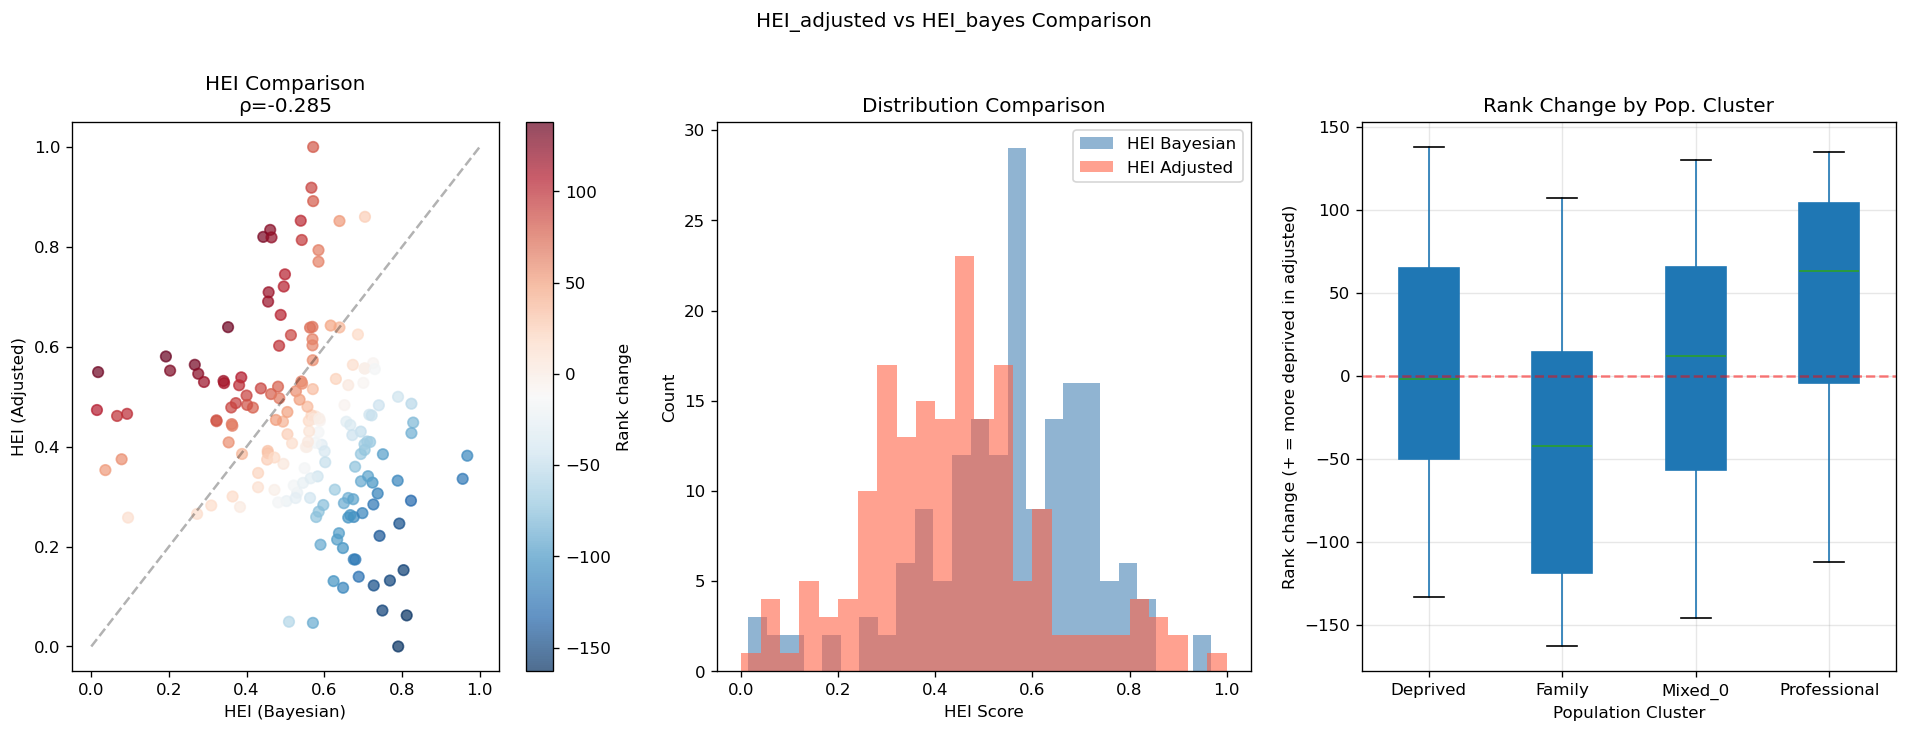

In [50]:
# --- 6.5  Comparison plots ---------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

# Scatter: HEI_bayes vs HEI_adjusted
ax = axes[0]
sc = ax.scatter(master['HEI_bayes'], master['HEI_adjusted'],
                c=master['rank_change'], cmap='RdBu_r', alpha=0.7, s=40)
plt.colorbar(sc, ax=ax, label='Rank change')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_xlabel('HEI (Bayesian)'); ax.set_ylabel('HEI (Adjusted)')
ax.set_title(f'HEI Comparison\nρ={rho_compare:.3f}')

# Distribution comparison
ax = axes[1]
ax.hist(master['HEI_bayes'], bins=25, alpha=0.6, color='steelblue', label='HEI Bayesian')
ax.hist(master['HEI_adjusted'], bins=25, alpha=0.6, color='tomato', label='HEI Adjusted')
ax.set_xlabel('HEI Score'); ax.set_ylabel('Count')
ax.set_title('Distribution Comparison')
ax.legend()

# Rank change by population cluster
ax = axes[2]
master.boxplot(column='rank_change', by='pop_label', ax=ax,
               patch_artist=True, return_type='dict')
ax.set_title('Rank Change by Pop. Cluster')
ax.set_xlabel('Population Cluster'); ax.set_ylabel('Rank change (+ = more deprived in adjusted)')
ax.axhline(0, color='red', linestyle='--', alpha=0.5)
plt.suptitle('')
ax.grid(alpha=0.3)

plt.suptitle('HEI_adjusted vs HEI_bayes Comparison', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'hei_adjusted_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

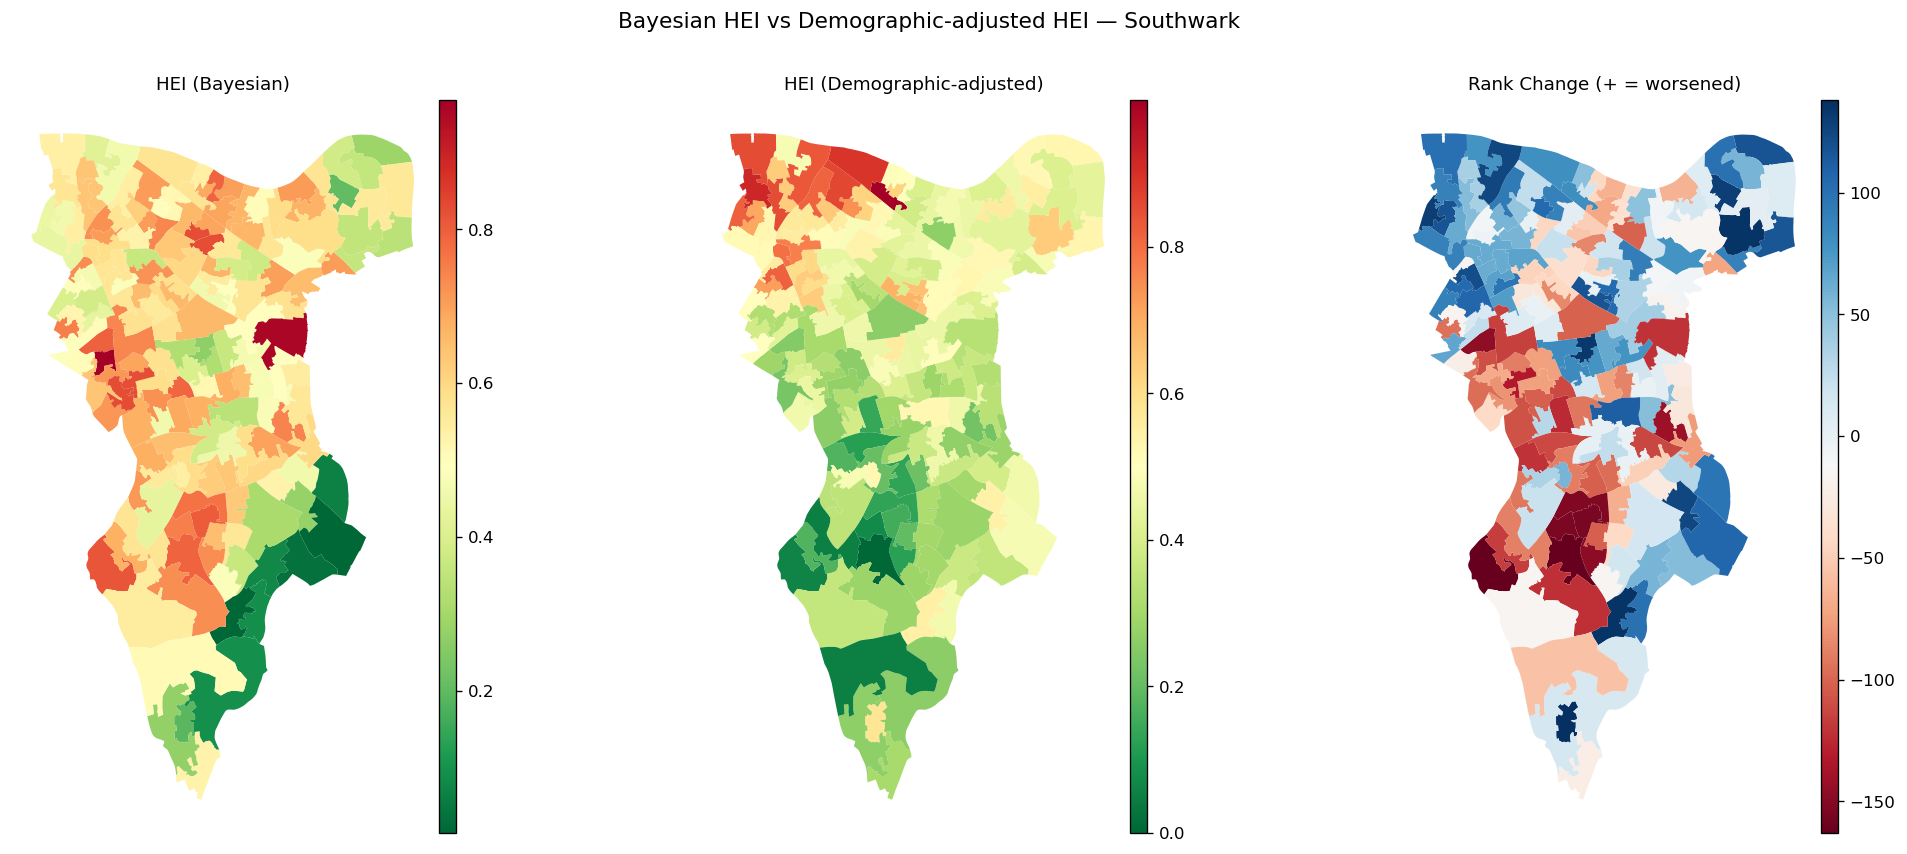

In [51]:
# --- 6.6  Side-by-side map: HEI_bayes vs HEI_adjusted -----------------------
geo_adj = geo_swk.merge(
    master[['lsoa21cd', 'HEI_bayes', 'HEI_adjusted', 'rank_change']].drop_duplicates('lsoa21cd'),
    left_on=geo_col, right_on='lsoa21cd', how='left')

for col in ['HEI_bayes', 'HEI_adjusted', 'rank_change']:
    geo_adj[col] = geo_adj[col].fillna(geo_adj[col].median())

fig, axes = plt.subplots(1, 3, figsize=(18, 7))

from mpl_toolkits.axes_grid1 import make_axes_locatable

for ax, (col, title, cmap) in zip(axes, [
    ('HEI_bayes',    'HEI (Bayesian)',           'RdYlGn_r'),
    ('HEI_adjusted', 'HEI (Demographic-adjusted)', 'RdYlGn_r'),
    ('rank_change',  'Rank Change (+ = worsened)',  'RdBu'),
]):
    divider = make_axes_locatable(ax)
    cax = divider.append_axes('right', size='4%', pad=0.05)
    geo_adj.plot(column=col, cmap=cmap, legend=True, ax=ax, cax=cax,
                 missing_kwds={'color': 'lightgrey'})
    ax.set_title(title, fontsize=11); ax.axis('off')

plt.suptitle('Bayesian HEI vs Demographic-adjusted HEI — Southwark', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'hei_adjusted_map.png'), dpi=150, bbox_inches='tight')
plt.show()

## Section 7 — Save Results

In [52]:
# --- 7.1  Save master analysis table -----------------------------------------
SAVE_COLS = ['lsoa21cd', 'lsoa21nm', 'HEI_bayes', 'HEI_bayes_uncert',
             'HEI_quintile', 'HEI_adjusted', 'rank_bayes', 'rank_adjusted', 'rank_change',
             'pop_cluster', 'pop_label', 'zone_type'] + DEMO_COLS + HEI_COMPONENTS

out = master[[c for c in SAVE_COLS if c in master.columns]].drop_duplicates('lsoa21cd')
out_path = os.path.join(DATA_DIR, 'southwark_rq5_population_sensitivity.csv')
out.to_csv(out_path, index=False)
print(f'✓ Saved: {out_path}  ({out.shape})')

# --- 7.2  Summary statistics table ------------------------------------------
print('\n=== Summary of Hypothesis Tests ===')
print(f'H1 (ANOVA): {sum(1 for r in anova_results if r["p_value"]<0.05)}/{len(anova_results)} demographic variables significantly differ across HEI quintiles')
print(f'H2 (Spearman): {sum(1 for r in sens_results if r["p_value"]<0.05)}/{len(sens_results)} demographic-HEI component pairs significantly correlated')
print(f'H3 (Chi-sq): chi2={chi2:.2f}, p={p_chi2:.4f} ({"significant" if p_chi2<0.05 else "not significant"})')
n_dd = (master['zone_type'] == 'Double Deprivation').sum()
n_da = (master['zone_type'] == 'Double Advantage').sum()
print(f'H3 (Zones): {n_dd} Double Deprivation LSOAs | {n_da} Double Advantage LSOAs')
print(f'HEI_adjusted: Spearman ρ with HEI_bayes = {rho_compare:.4f}')

✓ Saved: /Users/kevin/Desktop/代写/lxy/code/data/southwark_rq5_population_sensitivity.csv  ((173, 35))

=== Summary of Hypothesis Tests ===
H1 (ANOVA): 0/9 demographic variables significantly differ across HEI quintiles
H2 (Spearman): 4/8 demographic-HEI component pairs significantly correlated
H3 (Chi-sq): chi2=8.00, p=0.7849 (not significant)
H3 (Zones): 13 Double Deprivation LSOAs | 5 Double Advantage LSOAs
HEI_adjusted: Spearman ρ with HEI_bayes = -0.2846
